<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/06_lime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELL 1: Mount Drive and install LIME (FIXED)
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Install LIME
!pip install lime

# Clone repo using HTTPS with token or just copy from Drive
# Instead of cloning, let's just use the files we already have
import sys
sys.path.append('/content/xai-ids')

import numpy as np
import pandas as pd
import joblib
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")
print("📊 LIME imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete!
📊 LIME imported successfully!


In [ ]:
# ============================================
# CELL 2: Load Random Forest and test data
# ============================================

# Load the model
rf_model = joblib.load('/content/drive/MyDrive/xai-ids/results/models/random_forest.pkl')
print("✅ Random Forest model loaded")

# Load test data
data_path = '/content/drive/MyDrive/xai-ids/data/processed/nsl_kdd_processed.pkl'
data = joblib.load(data_path)
X_train = data['X_train']
X_test = data['X_test']
y_test = data['y_test']

print(f"📊 Training data shape: {X_train.shape}")
print(f"📊 Test data shape: {X_test.shape}")

# Use sample for faster computation
X_sample = X_test[:50]
y_sample = y_test[:50]
print(f"📊 Using {len(X_sample)} samples for LIME analysis")

✅ Random Forest model loaded
📊 Training data shape: (110442, 41)
📊 Test data shape: (22544, 41)
📊 Using 50 samples for LIME analysis


In [ ]:
# ============================================
# CELL 3: Create LIME explainer
# ============================================

# Create feature names (generic for now)
feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['Normal', 'Attack'],
    mode='classification',
    random_state=42
)

print("✅ LIME explainer created!")

✅ LIME explainer created!



🔍 Explaining sample 0 (Actual: Attack)

📊 Top features for this prediction:
--------------------------------------------------
Feature_3 <= -0.74: INCREASES attack probability by 0.0581
Feature_7 <= -0.09: DECREASES attack probability by 0.0558
Feature_11 <= -0.81: INCREASES attack probability by 0.0435
Feature_9 <= -0.10: DECREASES attack probability by 0.0381
Feature_10 <= -0.03: DECREASES attack probability by 0.0379
Feature_13 <= -0.04: INCREASES attack probability by 0.0362
Feature_28 <= -1.32: INCREASES attack probability by 0.0344
Feature_22 > 0.57: INCREASES attack probability by 0.0292
Feature_26 > -0.37: INCREASES attack probability by 0.0273
Feature_32 <= -0.95: INCREASES attack probability by 0.0239

✅ Explanation saved as HTML


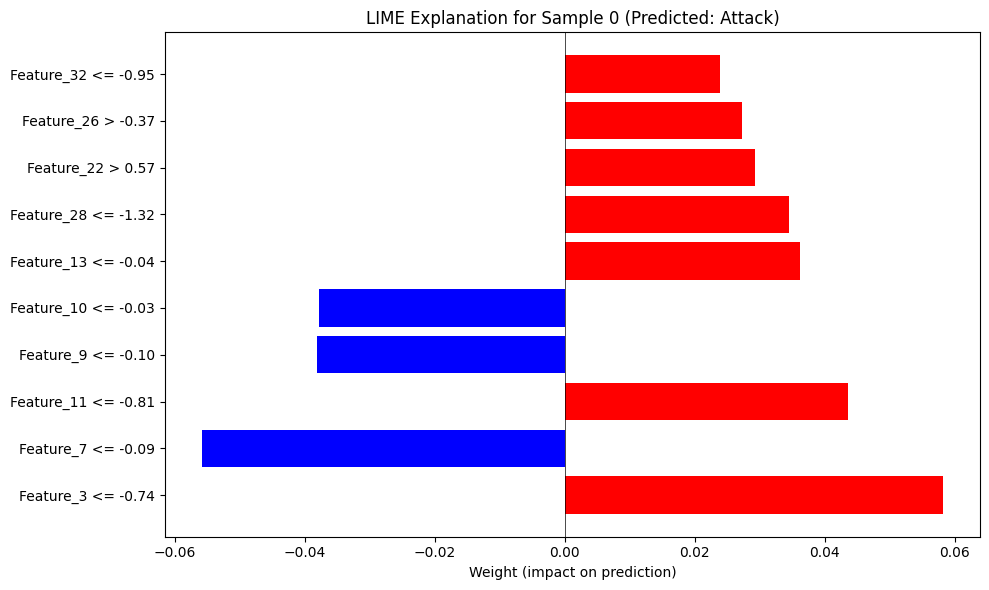

In [ ]:
# ============================================
# CELL 4: Explain one attack sample
# ============================================

# Find first attack sample
attack_indices = np.where(y_sample == 1)[0]
if len(attack_indices) > 0:
    idx = attack_indices[0]

    print(f"\n🔍 Explaining sample {idx} (Actual: Attack)")

    # Get LIME explanation
    exp = explainer.explain_instance(
        X_sample[idx],
        rf_model.predict_proba,
        num_features=10
    )

    # Print explanation
    print("\n📊 Top features for this prediction:")
    print("-" * 50)
    for feature, weight in exp.as_list():
        effect = "INCREASES" if weight > 0 else "DECREASES"
        print(f"{feature}: {effect} attack probability by {abs(weight):.4f}")

    # Save explanation as HTML
    exp.save_to_file('/content/drive/MyDrive/xai-ids/results/figures/lime_explanation.html')
    print("\n✅ Explanation saved as HTML")

    # Create a bar plot
    plt.figure(figsize=(10, 6))

    features, weights = zip(*exp.as_list())
    colors = ['red' if w > 0 else 'blue' for w in weights]

    plt.barh(range(len(features)), weights, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('Weight (impact on prediction)')
    plt.title(f'LIME Explanation for Sample {idx} (Predicted: Attack)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()

    plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/lime_bar_plot.png',
                dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("No attack samples found")

In [ ]:
# ============================================
# CELL 5: Explain multiple samples
# ============================================

print("\n📊 EXPLAINING MULTIPLE SAMPLES")
print("="*60)

lime_results = []

for idx in range(min(5, len(X_sample))):
    print(f"\n🔍 Sample {idx}:")
    print(f"   Actual: {'Attack' if y_sample[idx] == 1 else 'Normal'}")

    # Get prediction
    pred = rf_model.predict(X_sample[idx].reshape(1, -1))[0]
    proba = rf_model.predict_proba(X_sample[idx].reshape(1, -1))[0]
    print(f"   Predicted: {'Attack' if pred == 1 else 'Normal'} (Confidence: {max(proba):.2%})")

    # Get LIME explanation
    exp = explainer.explain_instance(
        X_sample[idx],
        rf_model.predict_proba,
        num_features=5
    )

    # Store results
    lime_results.append({
        'sample_idx': idx,
        'actual': 'Attack' if y_sample[idx] == 1 else 'Normal',
        'predicted': 'Attack' if pred == 1 else 'Normal',
        'confidence': max(proba),
        'explanation': exp.as_list()
    })

    # Print top 3 features
    print("   Top 3 features:")
    for feature, weight in exp.as_list()[:3]:
        effect = "INCREASES" if weight > 0 else "DECREASES"
        print(f"      - {feature}: {effect} by {abs(weight):.4f}")

# Save results
import pickle
with open('/content/drive/MyDrive/xai-ids/results/lime_results.pkl', 'wb') as f:
    pickle.dump(lime_results, f)
print("\n✅ LIME results saved to Drive")


📊 EXPLAINING MULTIPLE SAMPLES

🔍 Sample 0:
   Actual: Attack
   Predicted: Attack (Confidence: 100.00%)
   Top 3 features:
      - Feature_3 <= -0.74: INCREASES by 0.0590
      - Feature_11 <= -0.81: INCREASES by 0.0425
      - Feature_22 > 0.57: INCREASES by 0.0310

🔍 Sample 1:
   Actual: Attack
   Predicted: Attack (Confidence: 100.00%)
   Top 3 features:
      - Feature_3 <= -0.74: INCREASES by 0.0584
      - Feature_11 <= -0.81: INCREASES by 0.0401
      - Feature_28 <= -1.32: INCREASES by 0.0341

🔍 Sample 2:
   Actual: Normal
   Predicted: Normal (Confidence: 99.95%)
   Top 3 features:
      - -0.74 < Feature_3 <= 0.75: DECREASES by 0.0594
      - Feature_11 <= -0.81: INCREASES by 0.0438
      - -1.32 < Feature_28 <= 0.77: DECREASES by 0.0342

🔍 Sample 3:
   Actual: Attack
   Predicted: Attack (Confidence: 90.17%)
   Top 3 features:
      - -0.01 < Feature_4 <= -0.01: INCREASES by 0.1050
      - -0.74 < Feature_3 <= 0.75: DECREASES by 0.0586
      - Feature_11 <= -0.81: INCREASES

In [ ]:
# ============================================
# CELL 6: Quick comparison preview
# ============================================

print("\n" + "="*60)
print("📋 LIME ANALYSIS COMPLETE")
print("="*60)

print("""
**What we have now:**
✅ LIME explanations for multiple samples
✅ HTML visualization saved
✅ Bar plot saved
✅ Results saved for comparison

**Next up (Notebook 7):**
- Load SHAP values from previous notebook
- Load LIME results from this notebook
- Systematic comparison between methods
- Agreement metrics (Kendall's Tau)
- Which XAI method is more stable?
""")

print("\n📁 Files saved:")
print("   - results/figures/lime_explanation.html")
print("   - results/figures/lime_bar_plot.png")
print("   - results/lime_results.pkl")


📋 LIME ANALYSIS COMPLETE

**What we have now:**
✅ LIME explanations for multiple samples
✅ HTML visualization saved
✅ Bar plot saved
✅ Results saved for comparison

**Next up (Notebook 7):**
- Load SHAP values from previous notebook
- Load LIME results from this notebook
- Systematic comparison between methods
- Agreement metrics (Kendall's Tau)
- Which XAI method is more stable?


📁 Files saved:
   - results/figures/lime_explanation.html
   - results/figures/lime_bar_plot.png
   - results/lime_results.pkl
